# NBEATSx — Neural Basis Expansion con covariables

Arquitectura diseñada específicamente para forecasting de precio de electricidad con variables exógenas (Olivares et al., 2021 — *"Forecasting electricity prices with NBEATSx"*). Vía la librería `neuralforecast` (Nixtla).

Se entrena un modelo por horizonte (1, 7, 30 días), igual que con GluonTS/PatchTST, ya que `h` (horizonte) es un parámetro fijo del modelo. Requiere `pip install neuralforecast`.

In [1]:
%pip install neuralforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 3.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 MB 6.0 MB/s  0:00:11 eta 0:00:01
  Attempting uninstall: pytorch-lightning━━━━━━━━━━━━━━━━━ 4/7 [ray]
    Found existing installation: pytorch-lightning 2.6.5━━━━━━ 4/7 [ray]
    Uninstalling pytorch-lightning-2.6.5:━━━━━━━━━━━━━━━━━ 4/7 [ray]
      Successfully uninstalled pytorch-lightning-2.6.5━━━━━━━━ 4/7 [ray]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [neuralforecast]m [pytorch-lightning]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import r2_score, median_absolute_error, max_error
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATSx
import warnings
warnings.filterwarnings('ignore')

BASE = Path.cwd().parents[1] / 'data' / 'processed'
df = pd.read_parquet(BASE / 'dataset_consolidado.parquet')
df.index = pd.to_datetime(df.index)

covariables = ['gen_termica', 'ONI', 'aportes_energia_gwh']

train = df[df.index < '2025-08-01']
test = df[(df.index >= '2025-08-01') & (df.index <= '2026-07-31')]

print(f"Train: {len(train)} días | Test: {len(test)} días")

Train: 4595 días | Test: 365 días


## Formato largo requerido por neuralforecast (`unique_id`, `ds`, `y` + exógenas)

In [14]:
def a_formato_nf(data):
    df_nf = data[['precio_bolsa'] + covariables].copy()
    df_nf = df_nf.reset_index()
    df_nf.columns = ['ds'] + list(df_nf.columns[1:])  # fuerza el nombre de la primera columna
    df_nf = df_nf.rename(columns={'precio_bolsa': 'y'})
    df_nf.insert(0, 'unique_id', 'precio_bolsa')
    return df_nf


train_nf = a_formato_nf(train)
test_nf = a_formato_nf(test)

print(train_nf.head())
print(f"\nTrain: {len(train_nf)} filas | Test: {len(test_nf)} filas")

      unique_id         ds         y  gen_termica   ONI  aportes_energia_gwh
0  precio_bolsa 2013-01-01  161.8653  37567779.87 -0.55          124884800.0
1  precio_bolsa 2013-01-02  193.6470  50853051.00 -0.55          133792600.0
2  precio_bolsa 2013-01-03  184.4642  48810850.48 -0.55          122927200.0
3  precio_bolsa 2013-01-04  188.2384  47282234.55 -0.55          108007000.0
4  precio_bolsa 2013-01-05  178.6095  51259272.59 -0.55          111063800.0

Train: 4595 filas | Test: 365 filas


## Entrenamiento + walk-forward por horizonte

Un modelo NBEATSx por horizonte (h fijo al entrenar). En cada bloque del walk-forward, se predice con `nf.predict(df=..., futr_df=...)` pasando el contexto actualizado — sin reentrenar, igual que hicimos con GluonTS.

In [21]:
def entrenar_nbeatsx(horizonte, train_nf, input_size=90, max_steps=300):
    modelo = NBEATSx(
        h=horizonte,
        input_size=input_size,
        futr_exog_list=covariables,
        stack_types=['identity'],  # evita el conflicto de seasonality/trend con h=1; también más comparable entre horizontes
        scaler_type='standard',
        max_steps=max_steps,
        val_check_steps=25,
        early_stop_patience_steps=5
    )
    nf = NeuralForecast(models=[modelo], freq='D')
    nf.fit(df=train_nf, val_size=90)
    return nf

def walk_forward_nbeatsx(nf, train_nf, test_nf, test, pasos):
    predicciones, fechas_pred = [], []
    contexto_actual = train_nf.copy()

    for i in range(0, len(test), pasos):
        pasos_bloque = min(pasos, len(test) - i)
        bloque_test = test_nf.iloc[i:i+pasos_bloque].reset_index(drop=True)

        futr_esqueleto = nf.make_future_dataframe(df=contexto_actual)
        n = len(futr_esqueleto)

        futr_df = futr_esqueleto.copy()
        for col in covariables:
            valores = bloque_test[col].values
            if len(valores) < n:
                # último bloque parcial: repetir el último valor conocido para completar
                relleno = np.full(n - len(valores), valores[-1] if len(valores) > 0 else 0)
                valores = np.concatenate([valores, relleno])
            futr_df[col] = valores[:n]

        pred = nf.predict(df=contexto_actual, futr_df=futr_df)
        pred_valores = pred['NBEATSx'].values[:pasos_bloque]

        predicciones.extend(pred_valores)
        fechas_pred.extend(test.index[i:i+pasos_bloque])

        contexto_actual = pd.concat([contexto_actual, bloque_test], ignore_index=True)

    return pd.Series(predicciones, index=fechas_pred)

In [22]:
def encontrar_raiz_repo(marcador='.git'):
    actual = Path.cwd()
    while actual != actual.parent:
        if (actual / marcador).exists():
            return actual
        actual = actual.parent
    raise FileNotFoundError("No se encontró la raíz del repo")


def agregar_metricas(nombre, real, pred, archivo, horizonte):
    real = np.array(real); pred = np.array(pred)
    mae = np.mean(np.abs(real - pred))
    rmse = np.sqrt(np.mean((real - pred)**2))
    mape = np.mean(np.abs((real - pred) / real)) * 100
    smape = np.mean(2 * np.abs(real - pred) / (np.abs(real) + np.abs(pred))) * 100
    r2 = r2_score(real, pred)
    medae = median_absolute_error(real, pred)
    max_err = max_error(real, pred)
    sesgo = np.mean(pred - real)

    nueva_fila = pd.DataFrame([{
        'Modelo': nombre, 'Horizonte': horizonte,
        'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'MAPE (%)': round(mape, 2),
        'sMAPE (%)': round(smape, 2), 'R²': round(r2, 4), 'MedAE': round(medae, 2),
        'MaxError': round(max_err, 2), 'Sesgo': round(sesgo, 2)
    }])

    if archivo.exists():
        tabla = pd.read_parquet(archivo)
        tabla = tabla[~((tabla['Modelo'] == nombre) & (tabla['Horizonte'] == horizonte))]
        tabla = pd.concat([tabla, nueva_fila], ignore_index=True)
    else:
        tabla = nueva_fila
    tabla.to_parquet(archivo, index=False)
    print(f"'{nombre}' (horizonte={horizonte}d) guardado en {archivo}")
    return tabla


raiz = encontrar_raiz_repo()
archivo_tabla = raiz / 'data' / 'processed' / 'tabla_metricas.parquet'
print("Archivo de métricas:", archivo_tabla)

Archivo de métricas: /Users/maguverm/Documents/tesis-bolsa/data/processed/tabla_metricas.parquet


In [23]:
resultados_horizonte = {}
modelos_nf = {}

for horizonte in [1, 7, 30]:
    print(f"\n{'='*70}\nHorizonte: {horizonte} día(s) — entrenando NBEATSx\n{'='*70}")

    nf = entrenar_nbeatsx(horizonte, train_nf)
    modelos_nf[horizonte] = nf

    pred = walk_forward_nbeatsx(nf, train_nf, test_nf, test, pasos=horizonte)
    real = test['precio_bolsa'].loc[pred.index]

    mae = np.mean(np.abs(real - pred))
    rmse = np.sqrt(np.mean((real - pred)**2))
    mape = np.mean(np.abs((real - pred) / real)) * 100
    print(f"\nNBEATSx ({horizonte}d): MAE={mae:.2f} | RMSE={rmse:.2f} | MAPE={mape:.2f}%")

    agregar_metricas('NBEATSx', real, pred, archivo_tabla, horizonte)
    resultados_horizonte[horizonte] = {'pred': pred, 'real': real}

Seed set to 1
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 1.0 M  | train
--------------------------------------------------------------
1.0 M     Trainable params
0         Non-trainable params
1.0 M     Total params
4.084     Total estimated model params size (MB)
16        Modules in train mode
0         Modules in eval mode



Horizonte: 1 día(s) — entrenando NBEATSx


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]


NBEATSx (30d): MAE=85.74 | RMSE=108.91 | MAPE=35.93%
'NBEATSx' (horizonte=30d) guardado en /Users/maguverm/Documents/tesis-bolsa/data/processed/tabla_metricas.parquet


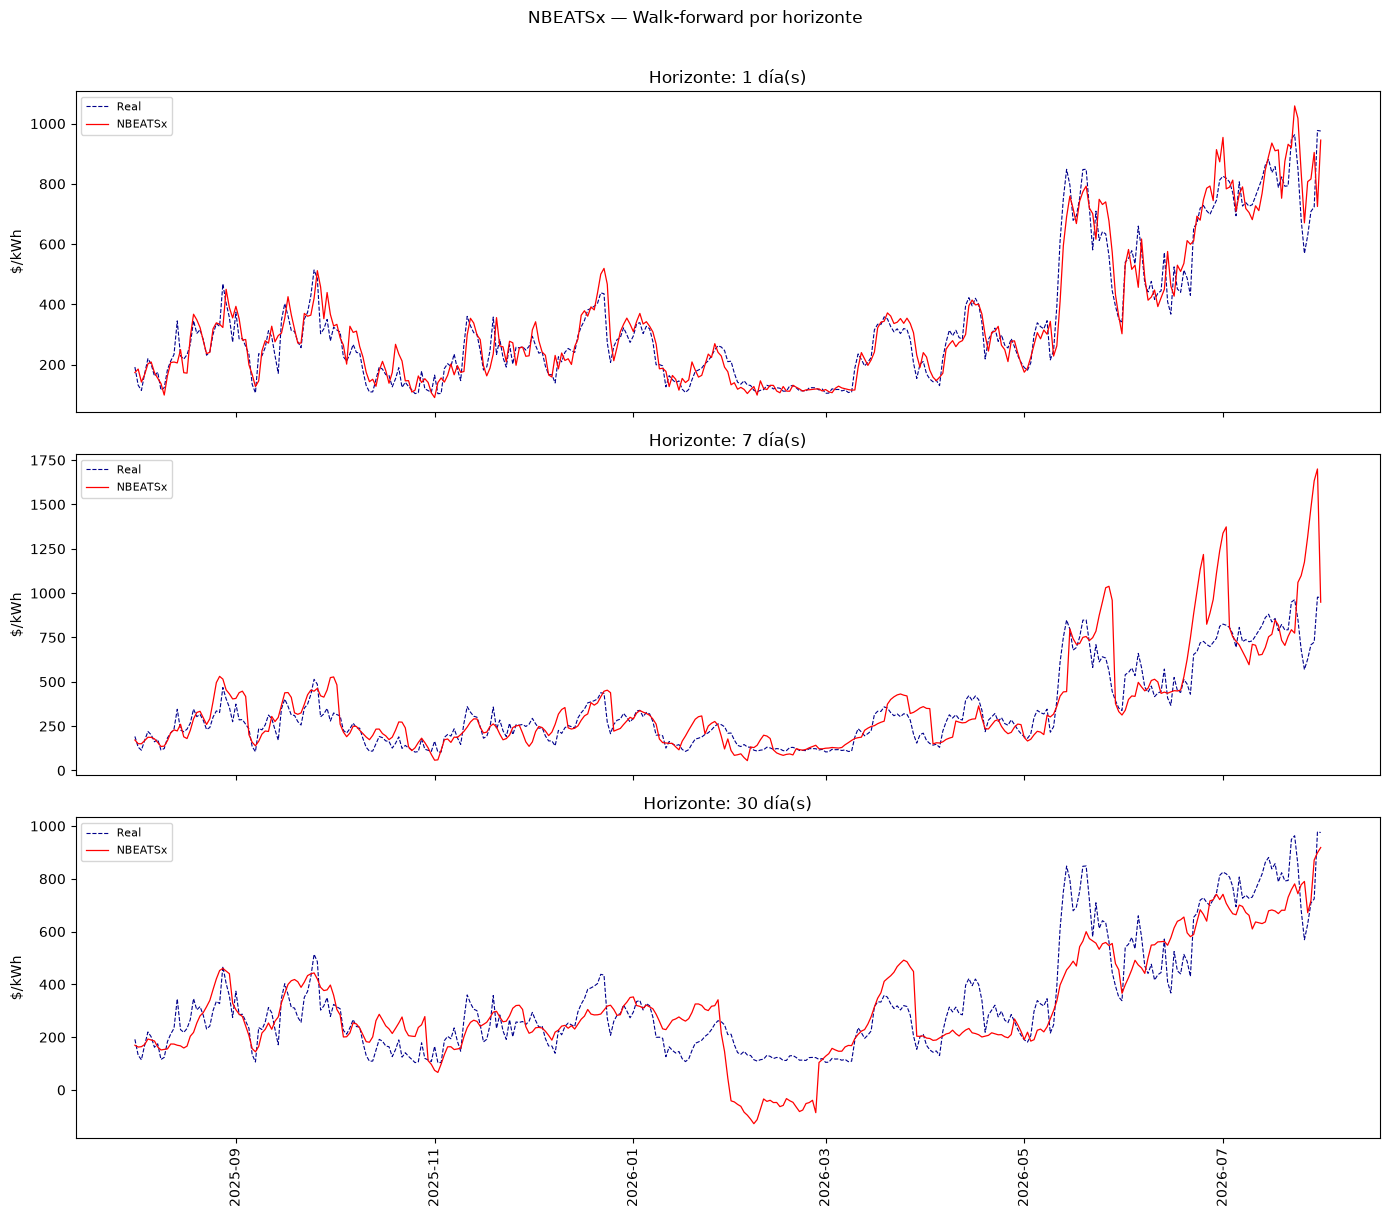

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for ax, h in zip(axes, [1, 7, 30]):
    r = resultados_horizonte[h]
    ax.plot(r['real'].index, r['real'].values, color='darkblue', linewidth=0.8, linestyle='--', label='Real')
    ax.plot(r['pred'].index, r['pred'].values, color='red', linewidth=0.9, label='NBEATSx')
    ax.set_ylabel('$/kWh')
    ax.set_title(f'Horizonte: {h} día(s)')
    ax.legend(fontsize=8)

axes[-1].tick_params(axis='x', rotation=90)
fig.suptitle('NBEATSx — Walk-forward por horizonte', y=1.01)
plt.tight_layout()
plt.show()

In [25]:
print(f"{'Horizonte':<12}{'SARIMAX':<12}{'NBEATSx':<12}")
sarimax_mae = {1: 40.30, 7: 56.65, 30: 74.53}
for h in [1, 7, 30]:
    mae_nbeatsx = np.mean(np.abs(resultados_horizonte[h]['real'] - resultados_horizonte[h]['pred']))
    print(f"{h:<12}{sarimax_mae[h]:<12}{mae_nbeatsx:<12.2f}")

Horizonte   SARIMAX     NBEATSx     
1           40.3        42.24       
7           56.65       83.38       
30          74.53       85.74       


In [26]:
# Covariable RONI futura (misma metodología ya usada en otros notebooks)
RONI_ULTIMO_OBSERVADO = 1.0
CATEGORIA_OUTLOOK = 'muy_fuerte'
PUNTOS_MEDIOS_CATEGORIA = {'debil': 0.7, 'moderado': 1.2, 'fuerte': 1.7, 'muy_fuerte': 2.3}
roni_objetivo = PUNTOS_MEDIOS_CATEGORIA[CATEGORIA_OUTLOOK]

fechas_futuras = pd.date_range('2026-08-01', '2026-08-30', freq='D')
roni_futuro = np.linspace(RONI_ULTIMO_OBSERVADO, roni_objetivo, len(fechas_futuras))

# gen_termica y aportes_energia_gwh: promedio estacional histórico
gen_termica_futuro = []
aportes_futuro = []
for fecha in fechas_futuras:
    mismo_dia = df[(df.index.month == fecha.month) & (df.index.day == fecha.day) & (df.index < '2026-08-01')]
    gen_termica_futuro.append(mismo_dia['gen_termica'].mean())
    aportes_futuro.append(mismo_dia['aportes_energia_gwh'].mean())

futr_df_futuro = pd.DataFrame({
    'unique_id': 'precio_bolsa',
    'ds': fechas_futuras,
    'gen_termica': gen_termica_futuro,
    'ONI': roni_futuro,
    'aportes_energia_gwh': aportes_futuro
})

# Contexto completo: train + test reales
contexto_completo = pd.concat([train_nf, test_nf], ignore_index=True)

nf_30 = modelos_nf[30]
forecast_futuro = nf_30.predict(df=contexto_completo, futr_df=futr_df_futuro)

print(f"Forecast NBEATSx al futuro: {fechas_futuras[0].date()} → {fechas_futuras[-1].date()}")
print(forecast_futuro[['ds', 'NBEATSx']])

Predicting: |          | 0/? [00:00<?, ?it/s]

Forecast NBEATSx al futuro: 2026-08-01 → 2026-08-30
           ds      NBEATSx
0  2026-08-01   961.078613
1  2026-08-02   885.127991
2  2026-08-03   938.408264
3  2026-08-04   952.073608
4  2026-08-05   988.151611
5  2026-08-06  1029.195557
6  2026-08-07  1038.382812
7  2026-08-08  1059.561035
8  2026-08-09  1110.160156
9  2026-08-10  1132.315186
10 2026-08-11  1174.484863
11 2026-08-12  1281.503662
12 2026-08-13  1320.571167
13 2026-08-14  1263.977661
14 2026-08-15  1199.712646
15 2026-08-16  1208.590576
16 2026-08-17  1149.114258
17 2026-08-18  1229.042480
18 2026-08-19  1266.660645
19 2026-08-20  1236.325684
20 2026-08-21  1241.530273
21 2026-08-22  1218.880615
22 2026-08-23  1164.367432
23 2026-08-24  1244.477661
24 2026-08-25  1309.593262
25 2026-08-26  1308.965210
26 2026-08-27  1374.404541
27 2026-08-28  1331.490967
28 2026-08-29  1348.769165
29 2026-08-30  1360.707275


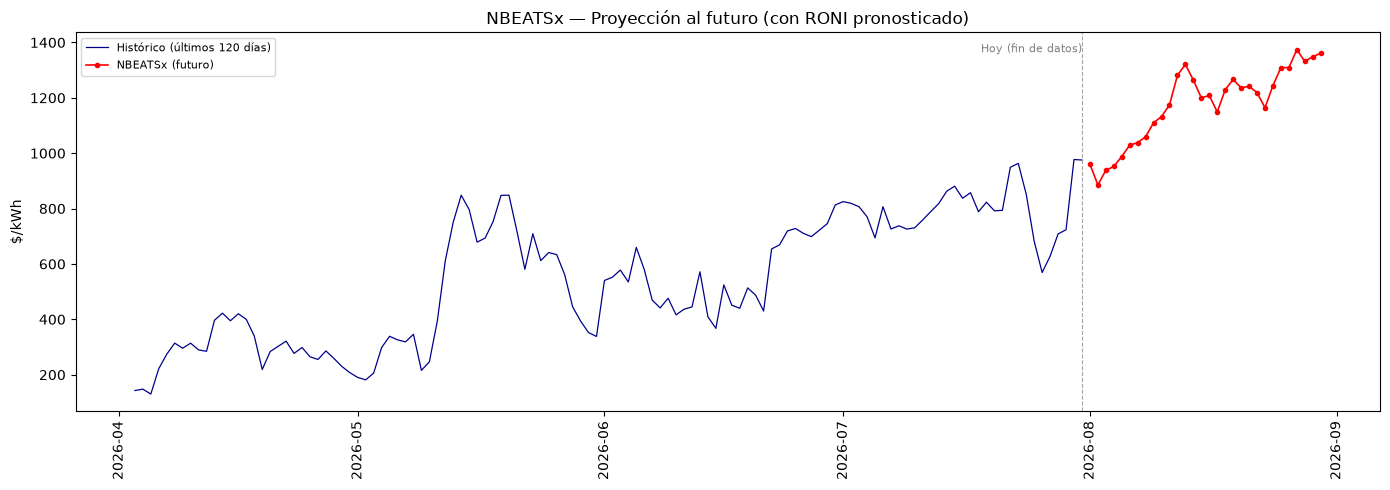

In [28]:
fig, ax = plt.subplots(figsize=(14, 5))

serie_completa = pd.concat([train['precio_bolsa'], test['precio_bolsa']])
contexto_reciente = serie_completa[-120:]

ax.plot(contexto_reciente.index, contexto_reciente.values, color='darkblue', linewidth=0.9, label='Histórico (últimos 120 días)')
ax.plot(forecast_futuro['ds'], forecast_futuro['NBEATSx'], color='red', linewidth=1.2, marker='o', markersize=3, label='NBEATSx (futuro)')

ax.axvline(serie_completa.index[-1], color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.text(serie_completa.index[-1], ax.get_ylim()[1]*0.95, 'Hoy (fin de datos)', fontsize=8, color='gray', ha='right')

ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title('NBEATSx — Proyección al futuro (con RONI pronosticado)')
plt.tight_layout()
plt.show()